### Importamos librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Importación del dataframe previa limpieza y transformación

In [4]:
df = pd.read_csv('../data/output/ecommerce-limpio.csv')

## Objetivo del Análisis:
### •	Describir y analizar la performance del flujo de ventas (timing de entrega, ventas completadas, ventas canceladas, “bottlenecks” o anomalías en la operativa). 
### •	Generar breve reporte de ventas, costos y beneficios. 
### •	Determinar eventuales insights de las ventas (estacionalidad, preferencias del usuario, formas de pagos, entre otros).


In [5]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,freight_value,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_message,review_creation_date,approval_status_flag,effective_sale
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,...,8.72,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,approved,True
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,...,8.72,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,approved,True
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,...,8.72,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,approved,True
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,...,22.76,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito bom o produto.,2018-08-08 00:00:00,approved,True
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,19.22,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,2018-08-18 00:00:00,approved,True


In [6]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'order_item_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_message', 'review_creation_date',
       'approval_status_flag', 'effective_sale'],
      dtype='str')

### Descripción de las variables:

* **order_id**: Identificador de la orden 
* **customer_id**: Identificador de cliente
* **order_status**: Estado de la orden
* **order_purchase_timestamp**: Fecha de realizada de la orden
* **order_approved_at**: Fecha de aprobada la orden
* **order_delivered_carrier_date**: Fecha de entrega al transportista
* **order_delivered_customer_date**: Fecha de entrega al cliente
* **order_estimated_delivery_date**: Fecha estimada de entrega al cliente
* **customer_unique_id**: Identificador único del cliente
* **customer_state**: Región donde habita el cliente
* **order_item_id**: Identificador de los ítems de la venta
* **shipping_limit_date**: Plazo límite del vendedor para entrega al transportista
* **price**: Precio del artículo
* **freight_value**: Costo de envío
* **payment_type**: Método de pago
* **payment_installments**: Número de cuotas
* **payment_value**: Valor del pago final
* **review_id**: Identificador de reseña
* **review_score**: Puntuación del cliente
* **review_comment_message**: Reseña del cliente
* **review_creation_date**: Fecha de realizada la reseña
* **approval_status_flag**: Indica si la orden fue aprobada
* **effective_sale**: Indica si la orden fue una venta exitosa

In [7]:
#obtengo un panorama general de mis variables numéricas 
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
order_item_id,119121.0,1.19,0.70,0.0,1.00,1.00,1.00,21.00
price,119121.0,119.81,183.76,0.0,39.90,73.90,132.70,6735.00
freight_value,119121.0,19.89,15.88,-1.0,12.95,16.24,21.15,409.68
payment_installments,119121.0,2.94,2.78,1.0,1.00,2.00,4.00,24.00
payment_value,119121.0,172.74,267.80,0.0,60.85,108.15,189.24,13664.08
review_score,119121.0,4.00,1.41,1.0,3.00,5.00,5.00,5.00


In [8]:
#chequeo formatos de las variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119121 entries, 0 to 119120
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119121 non-null  str    
 1   customer_id                    119121 non-null  str    
 2   order_status                   119121 non-null  str    
 3   order_purchase_timestamp       119121 non-null  str    
 4   order_approved_at              118959 non-null  str    
 5   order_delivered_carrier_date   117037 non-null  str    
 6   order_delivered_customer_date  115708 non-null  str    
 7   order_estimated_delivery_date  119121 non-null  str    
 8   customer_unique_id             119121 non-null  str    
 9   customer_state                 119121 non-null  str    
 10  order_item_id                  119121 non-null  int64  
 11  shipping_limit_date            118288 non-null  str    
 12  price                          119121 non

#### Convierto las columnas que contienen fechas a formato "datetime" para un uso eficiente de Pandas

In [9]:
#defino una función para convertir el formato
def transformar_columnas_fechas(df, lista_fechas):
    """
    Convierte múltiples columnas de un DataFrame a formato datetime.
    """
    for col in lista_fechas:
        #errors='coerce' transforma fechas mal formateadas en NaT (Not a Time) 
        df[col] = pd.to_datetime(df[col], errors='coerce')
    
    print(f'Se han transformado {len(lista_fechas)} columnas a datetime.')
    return df

In [10]:
#determino las variables
columnas_fechas = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date', 
    'shipping_limit_date', 
    'review_creation_date'
]

df = transformar_columnas_fechas(df, columnas_fechas)

#verifico rápidamente el cambio
print("\nVerificación de tipos:")
print(df[columnas_fechas].dtypes)

Se han transformado 7 columnas a datetime.

Verificación de tipos:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
shipping_limit_date              datetime64[us]
review_creation_date             datetime64[us]
dtype: object


In [19]:
#creo nuevas variables (mediante diferencias entre fechas) para métricas sobre el delay de entregas
df['delivery_delta'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = (df['delivery_delta'] > 0).astype(int)

### Abordaré mi análisis en 2 partes: 
#### **Parte A** *"Situación del negocio"*: Análisis descriptivo de variables de interés y principales correlaciones. Distribución de variables clave, y detección de fallos o vulnerabilidades en la operativa del negocio. El enfoque del análisis irá desde lo general a lo particular.
#### **Parte B** *"Rendimiento del negocio"*: KPIs de ventas, logística y operativa. Satisfacción del cliente. Identificar mejoras posibles.

In [20]:
#configuro un preset para mis visualizaciones
sns.set_theme(style="whitegrid")
PALETA_PRINCIPAL = "viridis"
PALETA_SECUNDARIA = "RdYlGn"

### **Parte A** *"Situación del negocio"*
#### Resumo mediante un cuadro de gráficos la distribución de variables principales

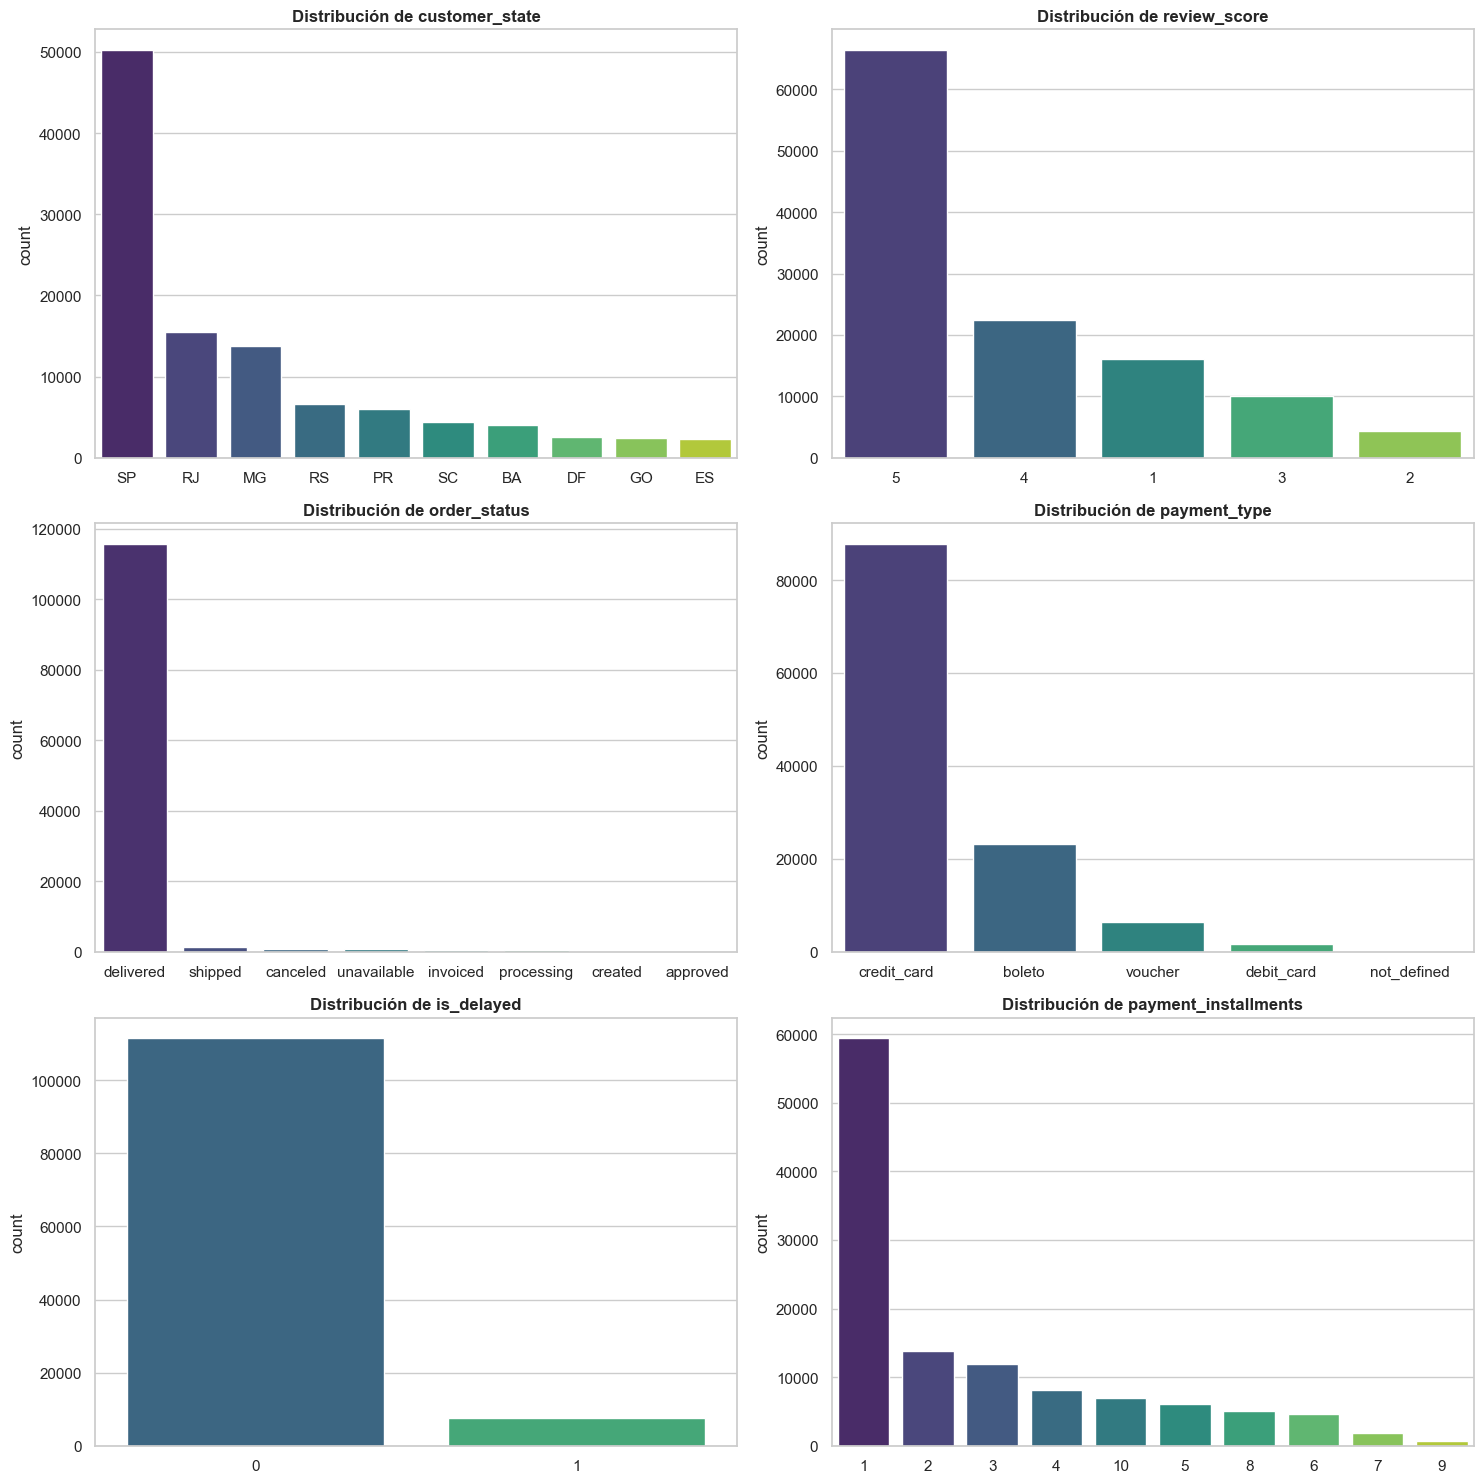

In [21]:
#defino una función para obtener un overview del negocio
def plot_overview_negocio(df, columnas):
    """
    Crea un cuadro de gráficos de conteo para un overview rápido.
    """
    n_cols = 2
    n_rows = (len(columnas) + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(columnas):
        sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", 
                      order=df[col].value_counts().index[:10])
        axes[i].set_title(f'Distribución de {col}', fontweight='bold')
        axes[i].set_xlabel('')

    #elimina ejes vacíos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

#variables a analizar
columnas_graficos = ['customer_state', 'review_score', 'order_status', 'payment_type', 'is_delayed', 'payment_installments']
plot_overview_negocio(df, columnas_graficos)

### *Primeros Insights:*
##### - Las ventas se concentran en el estado de San Pablo (SP) lo que indica una alta centralización logística lo que suguiere analizar el timing de entregas en dicha región (para detectar fallas o implementar mejoras). 
##### - El método de pago dominante es la tarjeta de crédito, y a pesar de que domina el pago único analizaré luego el impacto de las cuotas en el ticket promedio y el perfil del cliente que compra a crédito. 
##### - Las Reviews presentan una distribución "buena" aunque se debe explorar las calificaciones de 1 estrella (que no son mínimas). 
##### - En cuanto a la entrega de los pedidos la gran mayoría han sido entregados sin retrasos.

### Análisis correlacional:

In [22]:
#defino un plot para correlaciones de variables
def plot_matriz_correlacion(df, variables, titulo="Matriz de Correlación"):
    """
    Genera un heatmap de correlación mostrando solo el triángulo inferior.
    """
    plt.figure(figsize=(8, 6))
    correlation = df[variables].corr()
    
    #creo una máscara para optimizar la salida
    mask = np.triu(np.ones_like(correlation, dtype=bool))
    
    sns.heatmap(
        correlation, 
        mask=mask,
        annot=True, 
        cmap=PALETA_SECUNDARIA, 
        fmt=".2f", 
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )
    
    plt.title(f"{titulo}\n", fontsize=15, fontweight='bold')
    plt.show()

#defino un plot para medir el impacto de "X" variable en la calificación de reseña
def plot_impacto_satisfaccion(df, x_col, y_col='review_score', titulo=""):
    """
    Compara una variable categórica contra el Review Score usando Boxplots.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df, 
        x=x_col, 
        y=y_col, 
        palette="Set2",
        showmeans=True, # Agregamos la media para mayor rigor estadístico
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
    )
    plt.title(f"{titulo}\n", fontsize=12, fontweight='bold')
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel("Puntuación de Reseña")
    plt.show()

#### Analizo correlaciones entre variables de costos, logística y calificación del cliente

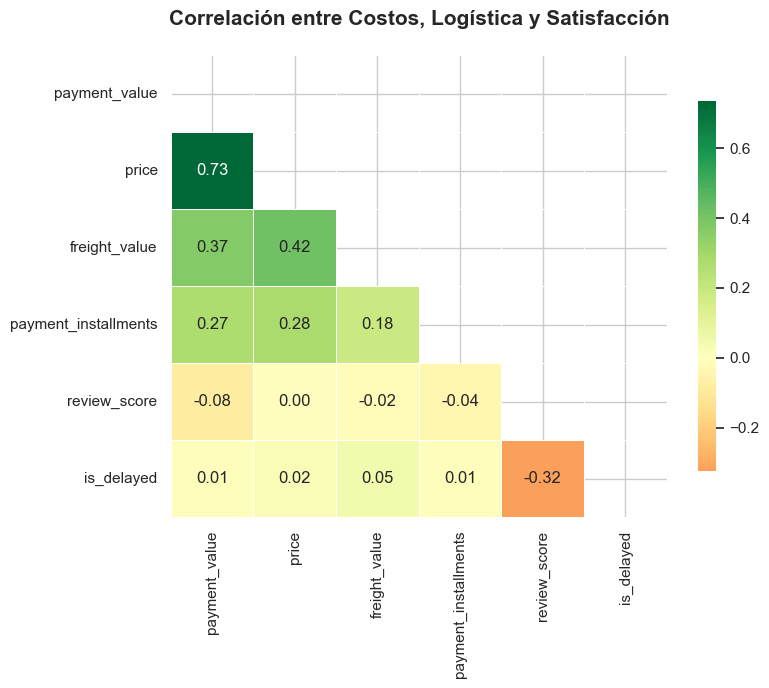

In [23]:
#defino variables para analizar correlaciones
vars_economicas = [
    'payment_value', 'price', 'freight_value', 
    'payment_installments', 'review_score', 'is_delayed'
]

#utilizo mi función pre-establecida para matriz de correlación
plot_matriz_correlacion(df, vars_economicas, 'Correlación entre Costos, Logística y Satisfacción')

#### Analizo cómo impacta el retraso de entregas *(is_delayed)* en la reseña del cliente *(review_score)*

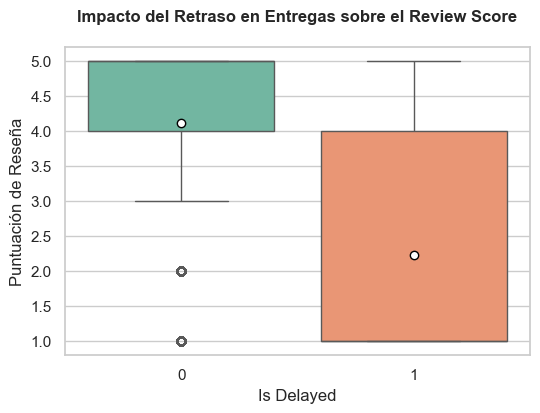

In [24]:
#impacto de la logística en la satisfacción del cliente
plot_impacto_satisfaccion(
    df, 
    x_col='is_delayed', 
    titulo="Impacto del Retraso en Entregas sobre el Review Score"
)


#### Analizo como se relaciona el Costo de Envío *(freight_value)* en el Pago Total del pedido *(payment_value)*

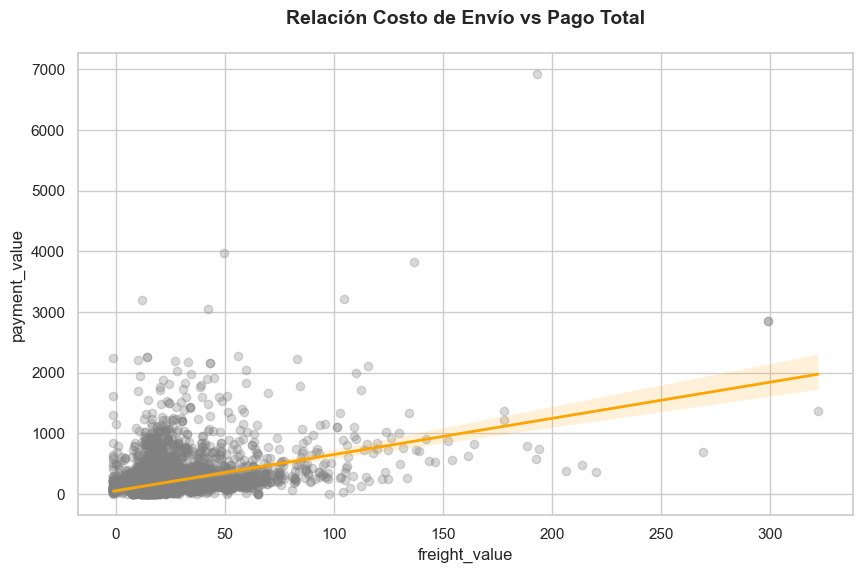

In [25]:
def plot_profundidad_correlacion(df, var_x, var_y, titulo):
    """
    Analiza la relación bivariada con línea de tendencia y densidad.
    """
    plt.figure(figsize=(10, 6))
    #tomamos una muestra aleatoria para agilizar el gráfico
    df_sample = df.sample(n=min(10000, len(df)), random_state=42)
    
    sns.regplot(
        data=df_sample, x=var_x, y=var_y, 
        scatter_kws={'alpha':0.3, 'color':'gray'}, 
        line_kws={'color':'orange', 'lw':2}
    )
    
    plt.title(f"{titulo}\n", fontsize=14, fontweight='bold')
    plt.show()

plot_profundidad_correlacion(df, 'freight_value', 'payment_value', "Relación Costo de Envío vs Pago Total")

#### La línea amarilla confirma que a mayor valor de pago suele haber un mayor costo de envío. Se observa un outlier de una venta de casi R$ 7000 con un costo de envío moderado. El principal insigth del gráfico es que el modelo de negocio se concentra en esa "nube" gris que representa cientos de ventas de bajo valor y envío barato.

### Analizo la relación del Número de Cuotas *(payment_installments)* y el Valor Total del pedido *(payment_value)*

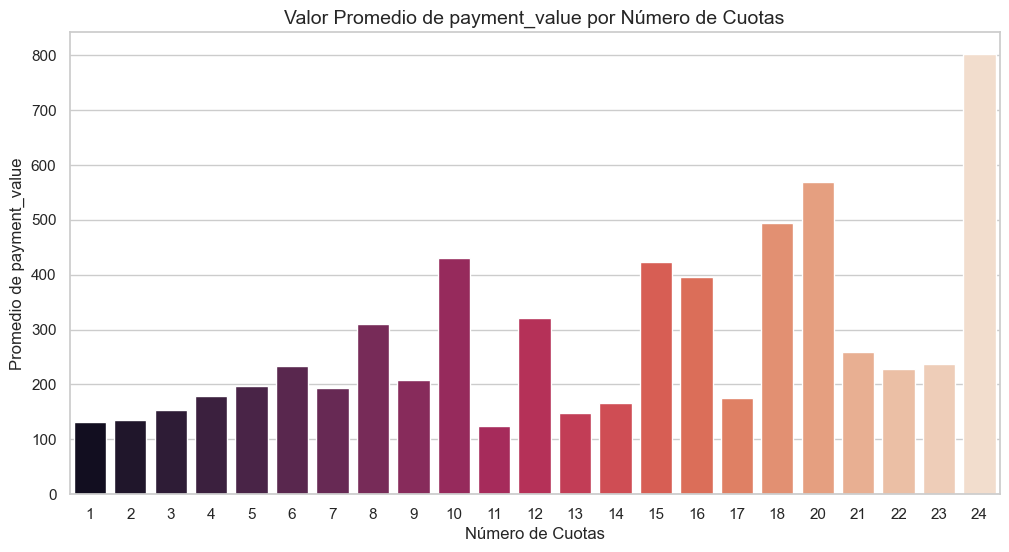

In [26]:
def plot_analisis_cuotas(df, var_valor):
    """
    Analiza cómo varía el valor (precio o pago) según el número de cuotas.
    """
    plt.figure(figsize=(12, 6))
    #usamos un barplot para ver el valor medio por cada número de cuotas
    sns.barplot(data=df, x='payment_installments', y=var_valor, palette='rocket', errorbar=None)
    
    plt.title(f"Valor Promedio de {var_valor} por Número de Cuotas", fontsize=14)
    plt.ylabel(f"Promedio de {var_valor}")
    plt.xlabel("Número de Cuotas")
    plt.show()

plot_analisis_cuotas(df, 'payment_value')

#### Se observa una tendencia creciente del financiamiento (escalonada de 2 a 6 cuotas) y luego picos en 10, 20 y 24 cuotas (plazos de financiamiento estándar en Brasil). Se observa un pico extremo de 24 cuotas sobre ventas de R$ 800 en promedio. A su vez, se puede ver una clara segmentación de 2 tipos de clientes que financian compras en el rango de R$ 100 - R$ 200: uno grupo lo hace de 2 a 5 cuotas mientras que el otro en 11-14 cuotas.

### Como último punto de la *parte A* del análisis: 
#### Analizo las 162 ordenes No Aprobadas (los nulos de "order_approved_at" que detecté en la limpieza y transformación previa de los datos)

In [ ]:
#determino el subconjunto de interés
vulnerabilidad_df = df[df['order_approved_at'].isnull()].copy()

#medidas de tendencia central para entender el peso financiero de la falla
print("--- Perfil Financiero de las Ordenes No Aprobadas ---")
print(vulnerabilidad_df['payment_value'].describe()[['mean', '50%', 'max', 'std']].to_frame().T.round(2))
print("-" * 50)

#distribución por Método de Pago (payment_type)
print("\n--- Frecuencia Relativa por Método de Pago ---")
print(vulnerabilidad_df['payment_type'].value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 50)

#impacto en la Satisfacción del cliente (review_score)
print("\n--- Impacto en el Review Score (Satisfacción) ---")
print(vulnerabilidad_df['review_score'].value_counts(normalize=True).sort_index().map('{:.2%}'.format))
print("-" * 50)

cols_interes = ['review_comment_message', 'payment_type', 'payment_value', 'review_score', 'order_status', 'order_purchase_timestamp']
print(f"\n--- Muestra Aleatoria de 10 Registros (de los {len(vulnerabilidad_df)} nulos) ---")
display(vulnerabilidad_df[cols_interes].sample(10))

--- Perfil Financiero de las Ordenes No Aprobadas ---
                 mean    50%      max    std
payment_value  217.86  107.5  3184.34  426.7
--------------------------------------------------

--- Frecuencia Relativa por Método de Pago ---
payment_type
voucher        53.09%
credit_card    35.19%
boleto          9.88%
not_defined     1.85%
Name: proportion, dtype: str
--------------------------------------------------

--- Impacto en el Review Score (Satisfacción) ---
review_score
1    41.36%
2    13.58%
3    10.49%
4     7.41%
5    27.16%
Name: proportion, dtype: str
--------------------------------------------------

--- Muestra Aleatoria de 10 Registros (de los 162 nulos) ---


,review_comment_message,payment_type,payment_value,review_score,order_status,order_purchase_timestamp
44354,Peço um produto por um código e vem outro tota...,voucher,94.63,1,canceled,2018-09-26 08:40:15
3686,NaN,voucher,206.88,3,canceled,2018-08-21 10:25:18
57340,NaN,credit_card,285.11,4,canceled,2017-05-25 16:12:51
31900,NaN,credit_card,117.85,5,canceled,2017-08-18 14:30:19
2142,O produto veio com defeito ele não liga não fu...,voucher,191.46,2,canceled,2018-09-20 13:54:16
116265,NaN,voucher,26.65,5,canceled,2017-06-07 20:11:29
6670,Super Recomendo..Um encanto :-),credit_card,123.25,5,canceled,2017-01-13 11:06:56
112517,NaN,voucher,310.34,3,canceled,2018-08-07 10:44:34
30713,"Produto entregue conforme anunciado, inclusive...",voucher,41.67,5,canceled,2017-08-31 23:55:57
2587,NaN,credit_card,72.90,5,canceled,2017-05-01 16:12:39


### Interpretación del análisis 
#### * **Voucher y Tarjeta de Crédito:** que un 53% de pedidos cancelados (sin orden aprobada) sean pagos con voucher sugiere un fallo en el procesamiento y la falta de aprobación del pago. A su vez, un 35% de pedidos con tarjeta de crédito y sin aprobación también suguiere un fallo técnico que debe revisar el área de desarrollo de APIs de pagos y pasarelas.
#### * **Reviews con Bajo Nivel:** que aproximadamente un 55% de estas ordenes presente reviews de 1 y 2 estrellas es esperable y justifica la falla en el proceso de compra para el cliente.
#### * **Paradoja en Reviews Altas:** no es esperable que el cliente muestre una satisfacción alta en un pedido sin orden de aprobación. Por esto decido profundizar en esos registros de 4 y 5 estrellas.

In [28]:
#filtramos las órdenes con éxito (4 y 5 estrellas) dentro del grupo objetivo
exito_en_falla_df = vulnerabilidad_df[vulnerabilidad_df['review_score'] >= 4].copy()

cols_auditoria = [
    'order_status', 
    'payment_type', 
    'payment_value', 
    'review_score', 
    'review_comment_message',
    'order_purchase_timestamp'
]

print(f"--- Auditoría de Comentarios: Clientes Satisfechos con Ordenes No Aprobadas ---")
print(f"Total de registros detectados con 4-5 estrellas: {len(exito_en_falla_df)}")
print("-" * 80)

#hago un sample de 25 ordenes sin aprobación con reseña 4-5 estrellas
display(exito_en_falla_df[cols_auditoria].sample(min(25, len(exito_en_falla_df))))

--- Auditoría de Comentarios: Clientes Satisfechos con Ordenes No Aprobadas ---
Total de registros detectados con 4-5 estrellas: 56
--------------------------------------------------------------------------------


,order_status,payment_type,payment_value,review_score,review_comment_message,order_purchase_timestamp
81732,canceled,voucher,222.03,5,Os produtos são de boa qualidade e o preço que...,2018-10-16 20:16:02
30708,canceled,credit_card,11.52,5,"Produto entregue conforme anunciado, inclusive...",2017-08-31 23:55:57
116268,canceled,voucher,37.01,5,NaN,2017-06-07 20:11:29
118924,canceled,voucher,63.89,5,NaN,2018-08-31 16:13:44
28843,canceled,credit_card,65.00,4,NaN,2017-07-25 19:26:15
112866,canceled,boleto,145.96,5,Fácil de montar!!!,2017-09-12 22:36:04
19720,canceled,credit_card,134.49,5,NaN,2017-12-23 22:25:00
85304,canceled,credit_card,173.82,5,NaN,2017-11-08 18:40:21
30712,canceled,voucher,41.67,5,"Produto entregue conforme anunciado, inclusive...",2017-08-31 23:55:57
6670,canceled,credit_card,123.25,5,Super Recomendo..Um encanto :-),2017-01-13 11:06:56


#### Podemos indicar (según las ordenes con reseñas) que en la mayoría de estos casos el cliente recibió el producto y está conforme. Esto suguiere un fallo técnico en la aprobación del pago, que a pesar de ello, el ciclo de la venta continuó y la orden fue entregada (algo realmente inusual), o bien que se trate de ventas "fantasmas". Se alertará de la falla en el informe final.

### **Parte B** *"Rendimiento del negocio"*:
### **Logística**
#### Calculamos KPIs de logística y determinamos en qué etapa del flujo logístico se producen incumplimientos

In [37]:
def analizar_performance_logistica(df):
    """
    Calcula KPIs de cumplimiento y determina responsables de retrasos.
    """
    df_log = df.copy()
    
    #diferencia entre entrega real al cliente y estimada
    df_log['delta_customer'] = (df_log['order_delivered_customer_date'] - df_log['order_estimated_delivery_date']).dt.days
    
    def categorizar_entrega(delta):
        if pd.isna(delta): 
            return 'No Entregado'
        if delta > 0: 
            return 'Fuera de Plazo'
        if delta == 0: 
            return 'En Tiempo'
        return 'Antes de Tiempo'
    
    df_log['entrega_status'] = df_log['delta_customer'].apply(categorizar_entrega)
    
    
    def determinar_responsable(row):
        if row['entrega_status'] != 'Fuera de Plazo':
            status_label = row['entrega_status'].lower()
            return f'N/A ({status_label})'
        
        vendedor_tarde = row['order_delivered_carrier_date'] > row['shipping_limit_date']
        
        if vendedor_tarde:
            return 'Vendedor (Límite de envío superado)'
        else:
            return 'Transportista (Demora en tránsito)'

    df_log['responsable_retraso'] = df_log.apply(determinar_responsable, axis=1)
    
    return df_log

df = analizar_performance_logistica(df)

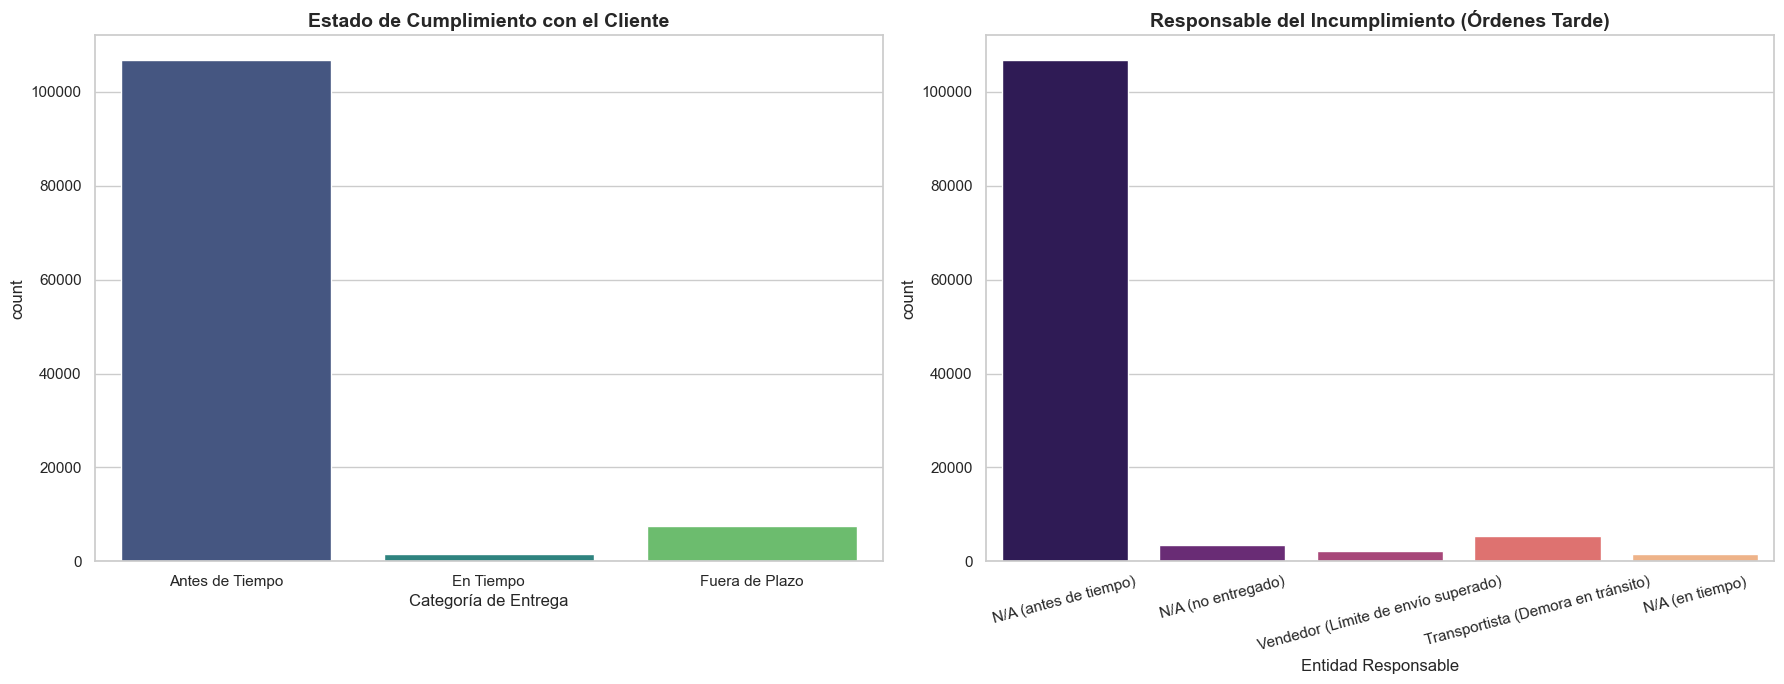

Resumen de Eficiencia Logística:
entrega_status
Antes de Tiempo    89.53%
Fuera de Plazo      6.34%
No Entregado        2.87%
En Tiempo           1.27%
Name: proportion, dtype: str


In [42]:
#configuracion del grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

#grafico 1: Estado General de las Entregas
order_status = ['Antes de Tiempo', 'En Tiempo', 'Fuera de Plazo']
sns.countplot(data=df, x='entrega_status', palette='viridis', order=order_status, ax=ax1)
ax1.set_title('Estado de Cumplimiento con el Cliente', fontsize=14, fontweight='bold')
ax1.set_xlabel('Categoría de Entrega')

#grafico 2: Quien incumple los plazos (solo ordenes con delay)
df_retrasos = df[df['responsable_retraso'] != 'N/A (A tiempo)']
sns.countplot(data=df_retrasos, x='responsable_retraso', palette='magma', ax=ax2)
ax2.set_title('Responsable del Incumplimiento (Órdenes Tarde)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Entidad Responsable')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("Resumen de Eficiencia Logística:")
print(df['entrega_status'].value_counts(normalize=True).map('{:.2%}'.format))

#### Observo que más del 90% de las ordenes que fueron entregadas dentro de los plazos preestablecidos. El 2,87% se debe a ordenes canceladas y productos fuera de stock (que representa pérdidas económicas). Profundizaré ahora en el 6,34% que excedió el plazo de entrega para determinar posibles mejoras en logística.

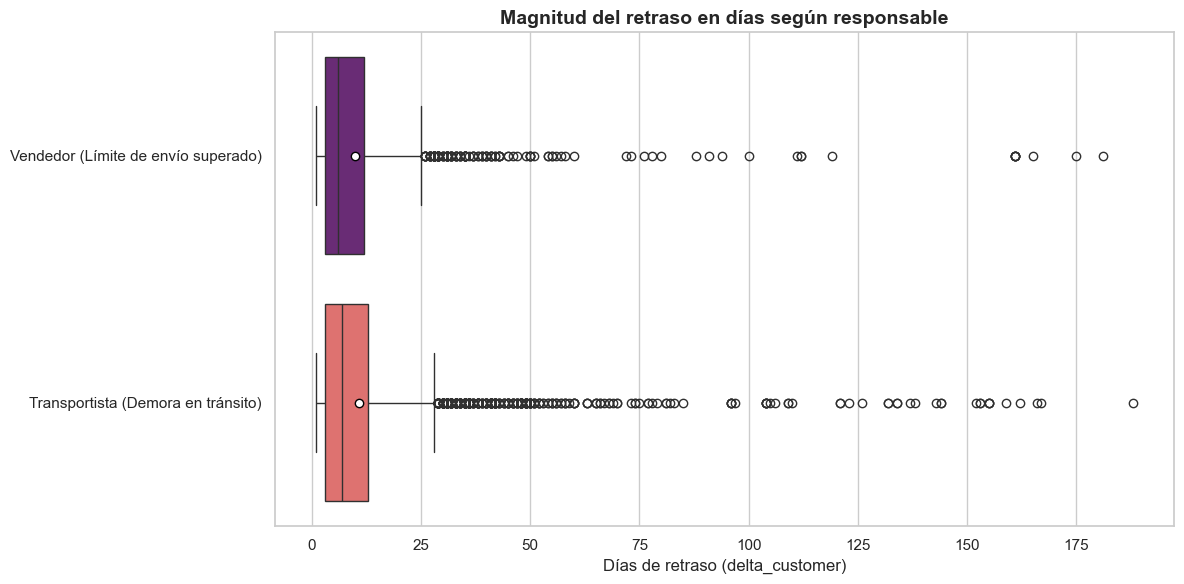


Resumen Estadístico de Días de Retraso por Responsable:


,count,mean,50%,max,std
responsable_retraso,,,,,
Transportista (Demora en tránsito),5379.0,10.81,7.0,188.0,14.68
Vendedor (Límite de envío superado),2176.0,9.96,6.0,181.0,14.49


In [43]:
def auditar_gravedad_retrasos(df):
    """
    Analiza la distribución de días de retraso segmentando por agente responsable.
    """
    #determino el subconjunto de interés
    df_tarde = df[df['entrega_status'] == 'Fuera de Plazo'].copy()
    
    #quito los N/A (a tiempo)
    df_tarde = df_tarde[df_tarde['responsable_retraso'] != 'N/A (a tiempo)']

    #configuro el boxplot para ver medianas y colas de distribución
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_tarde, 
        y='responsable_retraso', 
        x='delta_customer', 
        palette='magma',
        showmeans=True, 
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
    )
    
    plt.title('Magnitud del retraso en días según responsable', fontsize=14, fontweight='bold')
    plt.xlabel('Días de retraso (delta_customer)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    #estadísticos clave para complementar mi análisis
    print('\nResumen Estadístico de Días de Retraso por Responsable:')
    stats_retraso = df_tarde.groupby('responsable_retraso')['delta_customer'].describe()
    # Filtramos las métricas más relevantes para el reporte
    display(stats_retraso[['count', 'mean', '50%', 'max', 'std']].round(2))

auditar_gravedad_retrasos(df)

#### Con este análisis podemos ver "que hay" dentro de esos retrasos. Se asigna al transportista el mayor deterioro de la eficiencia logística en términos absolutos. Sin embargo tanto el vendedor como el transportista tienen retrasos similares en magnitud (con una mediana de 6 días el vendedor y 7 el transportista, ambos con máximos de +180 días). Veremos a qué regiones se corresponden estos retrasos y cómo impactan las reseñas. 

### **Satisfacción del Cliente**
### **Satisfacción del cliente** considerando logística:

In [44]:
def auditar_geografia_satisfaccion_retrasos(df):
    """
    Genera un reporte tabular del impacto de los retrasos en las reseñas
    y su concentración geográfica, incluyendo por estado la tasa de fallo interno.
    """
    #determino ordenes objetivo (fuera de plazo)
    df_tarde = df[df['entrega_status'] == 'Fuera de Plazo'].copy()
    
    #análisis de satisfacción (review_score)
    print("--- IMPACTO EN LA SATISFACCIÓN (Ordenes Fuera de Plazo) ---")
    print(df_tarde['review_score'].value_counts(normalize=True).sort_index().map('{:.2%}'.format))
    print("-" * 60)
    
    #análisis geográfico (customer_state)
    print("\n--- DISTRIBUCIÓN GEOGRÁFICA DE LOS RETRASOS (TOP 10) ---")
    
    #calculo la cantidad absoluta y el peso relativo dentro del problema
    retrasos_estado = df_tarde['customer_state'].value_counts().to_frame(name='Cant_Retrasos')
    retrasos_estado['%_del_Total_Retrasos'] = df_tarde['customer_state'].value_counts(normalize=True).map('{:.2%}'.format)
    
    #tasa de retraso interna: qué tan probable es que un pedido tenga retraso en cada región
    ventas_totales_estado = df['customer_state'].value_counts()
    retrasos_estado['Tasa_Fallo_Interna'] = (retrasos_estado['Cant_Retrasos'] / ventas_totales_estado * 100).round(2).astype(str) + '%'
    
    display(retrasos_estado.head(10))

auditar_geografia_satisfaccion_retrasos(df)

--- IMPACTO EN LA SATISFACCIÓN (Ordenes Fuera de Plazo) ---
review_score
1    54.78%
2     8.68%
3    10.55%
4     9.85%
5    16.14%
Name: proportion, dtype: str
------------------------------------------------------------

--- DISTRIBUCIÓN GEOGRÁFICA DE LOS RETRASOS (TOP 10) ---


,Cant_Retrasos,%_del_Total_Retrasos,Tasa_Fallo_Interna
customer_state,,,
SP,2100,27.80%,4.18%
RJ,1734,22.95%,11.18%
MG,582,7.70%,4.21%
BA,466,6.17%,11.39%
RS,370,4.90%,5.63%
SC,346,4.58%,7.96%
ES,247,3.27%,10.47%
PR,228,3.02%,3.77%
CE,202,2.67%,12.92%


#### Se observa claramente el impacto negativo del delay en la entrega de pedidos sobre la experiencia del usuario (considerando la review_score). Así mismo, destacamos las regiones con más pedidos retrasados en proporción al total de pedidos son: Ceará (CE), Espirito Santo (ES), Bahía (BA) y Rio de Janeiro (RJ). Para estados se suguiere implementar mejoras en logística (buscando transportistas más eficaces) o advertir al cliente al momento del check-out sobre un plazo de entrega más ajustado a la realidad.

In [45]:
#distribución general de review_score
dist_general = df['review_score'].value_counts(normalize=True).sort_index()

#distribución para pedidos fuera de plazo de review_score
dist_retrasos = df[df['entrega_status'] == 'Fuera de Plazo']['review_score'].value_counts(normalize=True).sort_index()

comparativa_tabla = pd.DataFrame({
    'General (%)': dist_general.map('{:.2%}'.format),
    'Fuera de Plazo (%)': dist_retrasos.map('{:.2%}'.format)
})

#añado la diferencia en puntos entre ambas distribuciones
comparativa_tabla['Diferencia (Puntos)'] = (dist_retrasos - dist_general).round(4)

print("--- COMPARATIVA DE SATISFACCIÓN: GENERAL VS. RETRASOS ---")
display(comparativa_tabla)

--- COMPARATIVA DE SATISFACCIÓN: GENERAL VS. RETRASOS ---


,General (%),Fuera de Plazo (%),Diferencia (Puntos)
review_score,,,
1,13.44%,54.78%,0.4134
2,3.59%,8.68%,0.0509
3,8.41%,10.55%,0.0214
4,18.79%,9.85%,-0.0894
5,55.77%,16.14%,-0.3963


#### Con esta comparativa podemos sostener que el retraso de los pedidos multiplica por 4 la probabilidad de recibir reseñas negativas (1 estrella), lo cual justifica financieramente cualquier inversión en logística que mejore los plazos de entrega. 

### **Satisfacción del cliente** considerando plan de financiación:
#### Segmento 2 grupos de clientes: grupo A (plan de 1-4 cuotas) y B (plan de 9-12 pagos) para analizar el impacto en las reseñas según la financiación elegida. El grupo A representa ventas en promedio de R$ 100 - 200, mientras que el B representa ventas de R$ 200 en promedio.

In [61]:
#defino los segmentos A y B
grupo_a = df[df['payment_installments'].between(1, 4)]
grupo_b = df[df['payment_installments'].between(9, 12)]

#hallo las distribuciones
dist_a = grupo_a['review_score'].value_counts(normalize=True).sort_index()
dist_b = grupo_b['review_score'].value_counts(normalize=True).sort_index()

#consolido con metadatos (N total) para hacerlo comparativo
comparativa_finan = pd.DataFrame({
    'Grupo A (1-4 cuotas) %': dist_a.map('{:.2%}'.format),
    'Grupo B (9-12 cuotas) %': dist_b.map('{:.2%}'.format)
})

print(f"--- COMPARATIVA DE SATISFACCIÓN POR FINANCIACIÓN ---")
print(f"Muestra Grupo A: {len(grupo_a)} registros")
print(f"Muestra Grupo B: {len(grupo_b)} registros")
display(comparativa_finan)

--- COMPARATIVA DE SATISFACCIÓN POR FINANCIACIÓN ---
Muestra Grupo A: 93226 registros
Muestra Grupo B: 7911 registros


,Grupo A (1-4 cuotas) %,Grupo B (9-12 cuotas) %
review_score,,
1,12.88%,17.89%
2,3.45%,4.06%
3,8.38%,8.91%
4,19.27%,15.81%
5,56.03%,53.33%


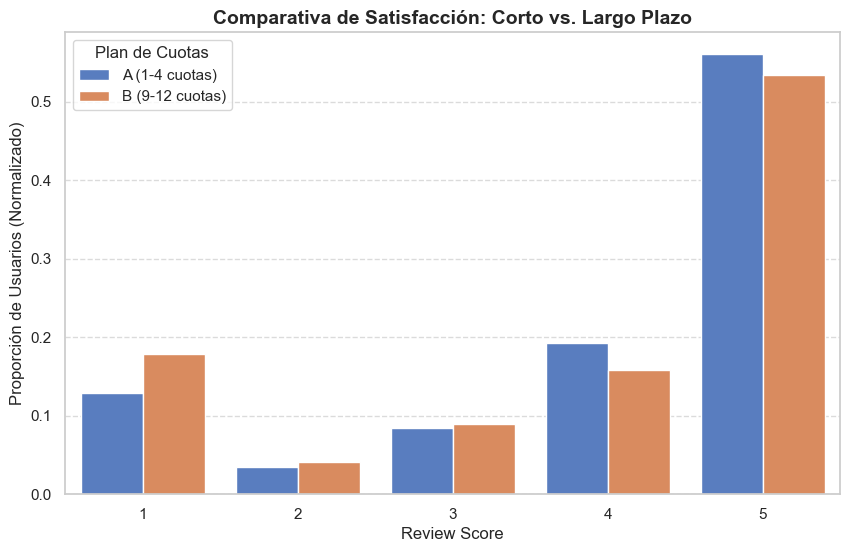

In [62]:
#creamos un dataframe temporal para el gráfico
df_a = grupo_a[['review_score']].copy()
df_a['Segmento'] = 'A (1-4 cuotas)'
df_b = grupo_b[['review_score']].copy()
df_b['Segmento'] = 'B (9-12 cuotas)'
df_plot = pd.concat([df_a, df_b])

#considero las proporciones dado que los grupos tienen distinto tamaño
plot_data = (df_plot.groupby(['Segmento', 'review_score'])
             .size()
             .groupby(level=0, group_keys=False)
             .apply(lambda x: x / x.sum())
             .reset_index(name='Proporción'))

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='review_score', y='Proporción', hue='Segmento', palette='muted')

plt.title('Comparativa de Satisfacción: Corto vs. Largo Plazo', fontsize=14, fontweight='bold')
plt.ylabel('Proporción de Usuarios (Normalizado)')
plt.xlabel('Review Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Plan de Cuotas')
plt.show()

#### De este análisis se desprende que financiaciones más largas (9-12 cuotas) deterioran sutilmente la calificación general respecto a financiaciones cortas. La calificación de 3 estrellas, al ser un punto medio calificativamente, y en el que ambos grupos se asemejan, suguiere que la entrega o el producto puede mejorar (independientemente del número de cuotas se haya elegido).
#### Es esperable que una calificación baja (1 estrella) sea superior para planes largos de financiación donde el componente de "aún lo estoy pagando" influye en la experiencia general del cliente.

### **Análisis ROI** *(Retorno de la Inversión)*
#### Información global de la facturación total según *estado geográfico* y *plan de financiación*

       --- PANORAMA GENERAL DE VENTAS (GMV) ---        
Facturación Total Histórica:  $20,577,136.51
-------------------------------------------------------
Top 5 Estados con Mayor Concentración:
 - SP   : $   7,724,594.73 (37.5%)
 - RJ   : $   2,795,265.83 (13.6%)
 - MG   : $   2,350,929.38 (11.4%)
 - RS   : $   1,159,527.95 (5.6%)
 - PR   : $   1,079,795.49 (5.2%)

Distribución por Plan de Financiación:
 - 1 a 4      cuotas: $13,009,135.32 (63.2%)
 - 5 a 8      cuotas: $4,238,628.45 (20.6%)
 - 9 a 12     cuotas: $3,220,470.21 (15.7%)
 - 13 a 16    cuotas: $   47,551.59 (0.2%)
 - 17 a 20    cuotas: $   32,073.47 (0.2%)
 - 21 a 24+   cuotas: $   29,277.47 (0.1%)


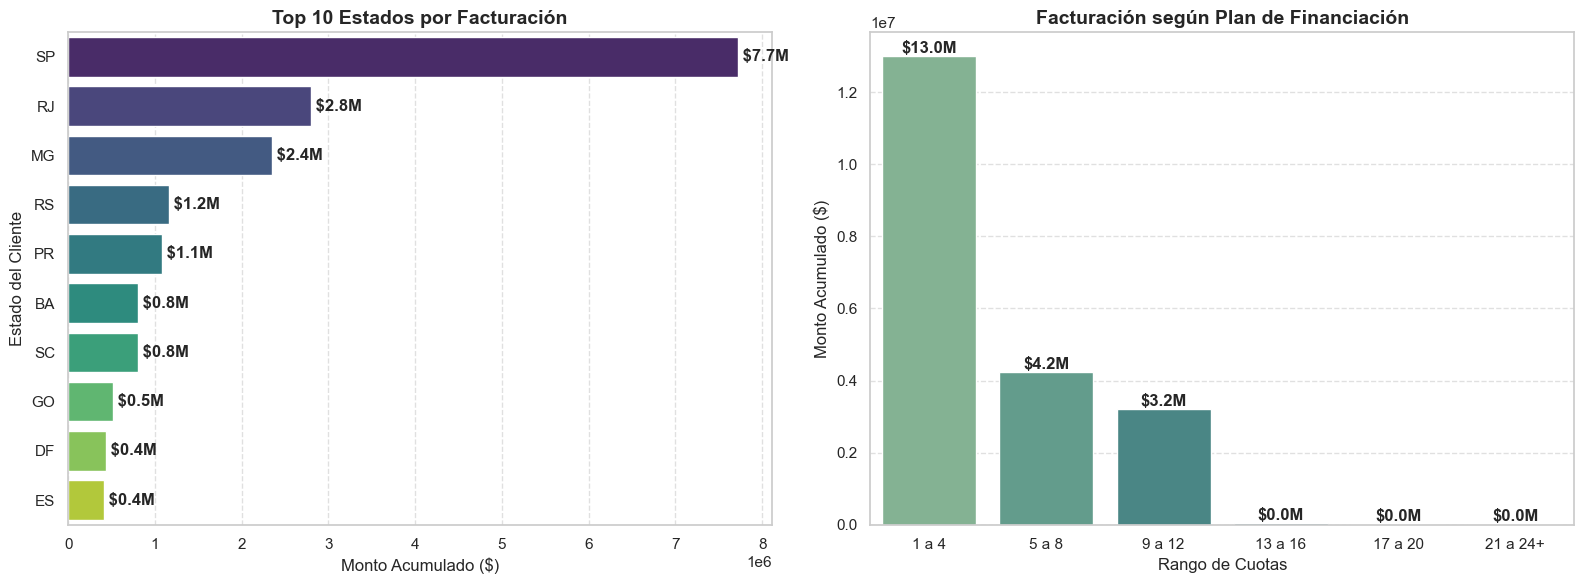

In [ ]:
#calculo el total de facturación por ventas
total_ventas = df['payment_value'].sum()

#agrupación geográfica por estados (top 10)
ventas_por_estado = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)
top_10_estados = ventas_por_estado.head(10)

#segmento en 6 grupos la financiación
bins = [0, 4, 8, 12, 16, 20, 25]
etiquetas = ['1 a 4', '5 a 8', '9 a 12', '13 a 16', '17 a 20', '21 a 24+']

#creo la columna de la segmentación y agrupo
df['rango_cuotas'] = pd.cut(df['payment_installments'], bins=bins, labels=etiquetas, right=True)
ventas_por_cuotas = df.groupby('rango_cuotas', observed=False)['payment_value'].sum()

print(f"{'--- PANORAMA GENERAL DE VENTAS ---':^55}")
print(f"Facturación Total Histórica:  ${total_ventas:,.2f}")
print("-" * 55)

print("Top 5 Estados con Mayor Concentración:")
for estado, valor in ventas_por_estado.head(5).items():
    porcentaje = (valor / total_ventas) * 100
    print(f" - {estado:<5}: ${valor:>15,.2f} ({porcentaje:.1f}%)")

print("\nDistribución por Plan de Financiación:")
for rango, valor in ventas_por_cuotas.items():
    if pd.notna(valor) and valor > 0:
        porcentaje = (valor / total_ventas) * 100
        print(f" - {rango:<10} cuotas: ${valor:>12,.2f} ({porcentaje:.1f}%)")

#visualizaciones
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#gráfico A: Ventas por Estado
sns.barplot(x=top_10_estados.values, y=top_10_estados.index, palette='viridis', ax=ax1)
ax1.set_title('Top 10 Estados por Facturación', fontsize=14, fontweight='bold')
ax1.set_xlabel('Monto Acumulado ($)')
ax1.set_ylabel('Estado del Cliente')
ax1.grid(axis='x', linestyle='--', alpha=0.6)

#formato millones para no saturar el gráfico
for i, v in enumerate(top_10_estados.values):
    ax1.text(v, i, f' ${v/1000000:.1f}M', va='center', fontweight='bold')

#gráfico B: Ventas por Cuotas
sns.barplot(x=ventas_por_cuotas.index, y=ventas_por_cuotas.values, palette='crest', ax=ax2)
ax2.set_title('Facturación según Plan de Financiación', fontsize=14, fontweight='bold')
ax2.set_xlabel('Rango de Cuotas')
ax2.set_ylabel('Monto Acumulado ($)')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

#agrego etiquetas de valor sobre las barras
for i, v in enumerate(ventas_por_cuotas.values):
    if pd.notna(v) and v > 0:
        ax2.text(i, v, f'${v/1000000:.1f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#### 1. *Concentración geográfica* 
#### La facturación global del negocio asciende a 20,5 millones de reales y las ventas están fuertemente concentradas en el estado de San Pablo (37,5%). Hay una hiper-dependecia de dicha región, lo que implica que el ROI es muy sensible a lo que allí suceda. Por ejemplo un ahorro de 1% en los costos de envíos para SP podría impactar más en el resultado del negocio que duplicar ventas en los estados del norte (GO, DF, ES). Esta concentración también respalda cualquier inverisón en campañas de marketing o almacenes en esa zona para evitar pérdidas por fuera de stock. 
#### 2. *Financiación corta* 
#### Los clientes optan por planes de financiación principalmente cortos, siendo el plan de hasta 4 cuotas el más preferido (63,2%) y el plazo anual actúa como un límite. Este hecho favorece el flujo de caja y la rápida liquidez del negocio, se puede decir que es financieramente 'saludable'.

### Impacto financiero de las 833 ordenes que representan ventas perdidas por falta de stock

 --- ANÁLISIS DE VENTAS PERDIDAS (fuera de stock) ---  
Pedidos no concretados:         833
Costo de Oportunidad Bruto:     $162,821.47
Impacto Reputacional (Est.):    $67,310.40
-------------------------------------------------------
Pérdida de Ingresos según Medio de Pago:
 - voucher        : $   26,729.16
 - not_defined    : $        0.00
 - debit_card     : $    2,884.06
 - credit_card    : $  105,975.47
 - boleto         : $   27,232.78


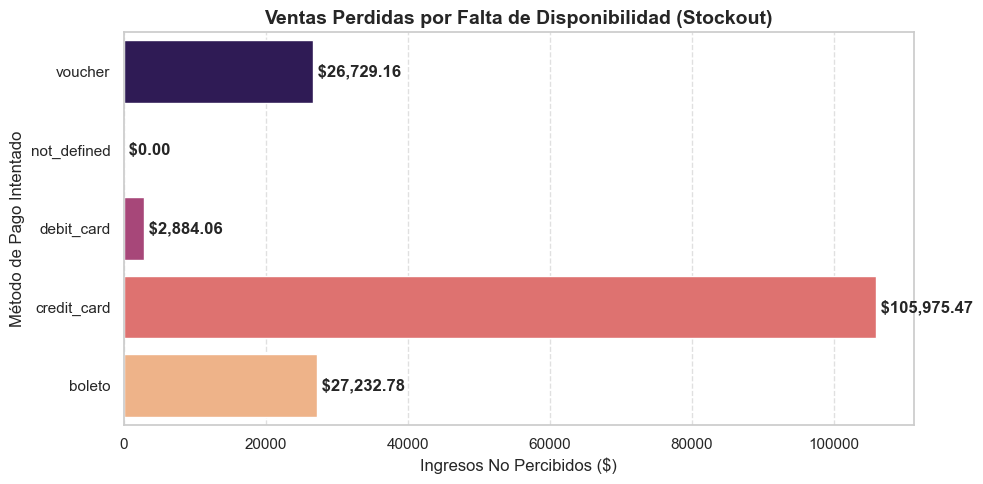

In [ ]:
#determino las ventas no concretadas (principalmente por falta de stock)
df_perdidas = df[df['effective_sale'] == False].copy()

#calculo el Costo de Oportunidad (usando 'valor_total' que es lo que la empresa dejó de facturar)
monto_perdido = df_perdidas['payment_value'].sum()
perdida_por_tipo = df_perdidas.groupby('payment_type')['payment_value'].sum().sort_index(ascending=False)

#calculo la "Pérdida Reputacional" (mediante la tasa de reseñas con 1 estrella = 41.34%)
tasa_detraccion = 0.4134 
impacto_reputacional = monto_perdido * tasa_detraccion

print(f"{'--- ANÁLISIS DE VENTAS PERDIDAS (fuera de stock) ---':^55}")
print(f"Pedidos no concretados:         {len(df_perdidas)}")
print(f"Costo de Oportunidad Bruto:     ${monto_perdido:,.2f}")
print(f"Impacto Reputacional (Est.):    ${impacto_reputacional:,.2f}")
print("-" * 55)

print("Pérdida de Ingresos según Medio de Pago:")
for tipo, valor in perdida_por_tipo.items():
    print(f" - {tipo:<15}: ${valor:>12,.2f}")

plt.figure(figsize=(10, 5))
sns.barplot(x=perdida_por_tipo.values, y=perdida_por_tipo.index, palette='magma')

for i, v in enumerate(perdida_por_tipo.values):
    plt.text(v, i, f' ${v:,.2f}', va='center', fontweight='bold')

plt.title('Ventas Perdidas por Falta de Disponibilidad (Stockout)', fontsize=14, fontweight='bold')
plt.xlabel('Ingresos No Percibidos ($)')
plt.ylabel('Método de Pago Intentado')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
#determino el peso de la pérdida sobre el total de lo facturado por ventas 
porcentaje_impacto = (monto_perdido / total_ventas) * 100

print(f"Ventas Totales del Dataset:  ${total_ventas_global:,.2f}")
print(f"Impacto sobre el Facturado:  {porcentaje_impacto:.2f}%")

Ventas Totales del Dataset:  $20,577,136.51
Impacto sobre el Facturado:  0.79%


#### Las ventas perdidas por falta de stock ascienden a R$ 162.821,47 (representando apenas un 0,79% del total de ventas) con un perfil de pago con tarjeta de crédito. Si bien es un costo de oportunidad relativamente bajo para la escala del negocio, es dinero que se pudo haber facturado y representa una insuficiencia en el flujo de ventas. Lo más crítico es que el 41,34% de esas ordenes no se volverían a realizar por parte del cliente (son clientes que debido a la mala experiencia no volverían, este es nuestro 'ratio de churn').

### Impacto financiero de las 162 ordenes No Aprobadas *(registros con error de procesamiento)*

In [ ]:
#calculo pérdida por error de procesamiento (ordenes canceladas)
df_error_tec = df[df['approval_status_flag'] == 'error_procesamiento'].copy()
monto_error_tec = df_error_tec['payment_value'].sum()
pct_error_tec = (monto_error_tec / total_ventas) * 100

#analisis Vouchers: calculamos la diferencia solo para los registros con voucher
df['descuento_voucher'] = 0.0
mask_v = df['payment_type'] == 'voucher'
df.loc[mask_v, 'descuento_voucher'] = df['valor_total'] - df['payment_value']

monto_total_vouchers = df['descuento_voucher'].sum()
pct_vouchers = (monto_total_vouchers / total_ventas) * 100

print(f"{'--- AUDITORÍA FINAL DE ROI Y DESCUENTOS ---':^55}")
print(f"Ventas Totales:             ${total_ventas:,.2f}")
print("-" * 55)

print(f"1. IMPACTO POR ERROR TÉCNICO (162 órdenes canceladas):")
print(f"   - Monto Perdido:               ${monto_error_tec:,.2f}")
print(f"   - % sobre Ventas Totales:      {pct_error_tec:.2f}%")
print("-" * 55)

print(f"2. ANÁLISIS DE VOUCHERS (Estrategia Comercial):")
print(f"   - Monto Total Descuentos:      ${monto_total_vouchers:,.2f}")
print(f"   - % sobre Ventas Totales:      {pct_vouchers:.2f}%")
print("-" * 55)

impacto_total_fugas = pct_error_tec + (162821.47 / total_ventas * 100) # Sumando el stockout anterior
print(f"FUGA TOTAL DE INGRESOS (Stockout + Incidencia Técnica): {impacto_total_fugas:.2f}%")

      --- AUDITORÍA FINAL DE ROI Y DESCUENTOS ---      
Ventas Totales:             $20,577,136.51
-------------------------------------------------------
1. IMPACTO POR ERROR TÉCNICO (162 órdenes canceladas):
   - Monto Perdido:               $35,293.02
   - % sobre Ventas Totales:      0.17%
-------------------------------------------------------
2. ANÁLISIS DE VOUCHERS (Estrategia Comercial):
   - Monto Total Descuentos:      $355,596.72
   - % sobre Ventas Totales:      1.73%
-------------------------------------------------------
FUGA TOTAL DE INGRESOS (Stockout + Error Técnico): 0.96%


#### Respecto a la incidencia técnica 'error de procesamiento' en las ordenes, ésta representa una pérdida de 0.17% en volumen de ventas respecto al total de ventas. Es un nivel bajo-regular. Se sugiere minimizar y monitorizar. De hecho, conjuntamente con las pérdidas por falta de stock, representan casi un 1% de las ventas totales, valor que no es alarmante, pero sí que debe mejorar.
#### El volumen de vouchers representa un 1.73% de las ventas totales y dejo a evaluar según criterios del equipo de finanzas (presupuestación) y marketing.

### Para finalizar exporto el dataframe para luego crear mi dashboard en Power BI

In [ ]:
df.to_csv(f'../data/output/ecommerce-for-dashboard.csv', index=False, encoding='utf-8')